# Proyek Klasifikasi Gambar:  **Scene Classification**
- **Nama:** Difa Fisabilillah
- **Email:** difafisabilillah91@gmail.com
- **ID Dicoding:** MC401D5X0255

## Import Packages/Library

In [ ]:
import os, shutil
import seaborn as sns
import matplotlib.pyplot as plt
from PIL import Image
import cv2
import pandas as pd
from sklearn.model_selection import train_test_split
from tqdm.auto import tqdm
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import load_model

## Data Preparation

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
cd './drive/MyDrive/Dicoding/Project 3_2/'

/content/drive/MyDrive/Dicoding/Project 3_2


Data Scene ini di dapatkan melalui proses Scraping melalui website pixeby <br>
berikut proses scraping : https://colab.research.google.com/drive/1nt_879tQZlLvUAfJIh3VpK2NLTIQ5YlN?usp=sharing

### Data Loading

In [ ]:
mountain = './Dataset/mountains/'
beach = './Dataset/beach/'
desert = './Dataset/desert/'
city = './Dataset/city/'

Data terdiri dari 4 jenis scene, yaitu:
1. Mountain
2. Beach
3. Desert
4. City

In [ ]:
all_file_mountains = len(os.listdir(mountain))
all_file_beach = len(os.listdir(beach))
all_file_desert = len(os.listdir(desert))
all_file_city = len(os.listdir(city))
jumlah_data_image = sum([all_file_desert, all_file_beach, all_file_city, all_file_mountains])
print(f'jumlah data : {jumlah_data_image}')

jumlah data : 10476


Total jumlah gambar dari keempat scene tersebut adalah 10.476 gambar

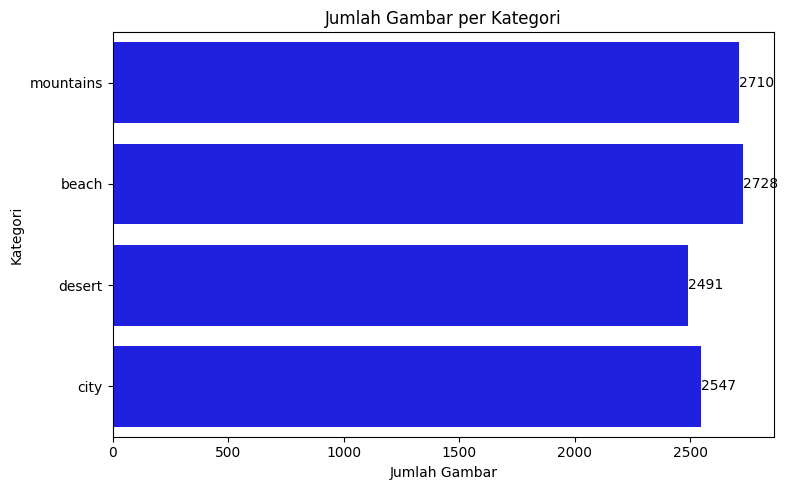

In [ ]:
kategori = ['mountains','beach', 'desert',  'city' ]
jumlah = [all_file_mountains, all_file_beach, all_file_desert, all_file_city]

plt.figure(figsize=(8, 5))
sns.barplot(x=jumlah, y=kategori, color='blue')

for i, v in enumerate(jumlah):
    plt.text(v + 1, i, str(v), va='center')

plt.title('Jumlah Gambar per Kategori')
plt.xlabel('Jumlah Gambar')
plt.ylabel('Kategori')

plt.tight_layout()
plt.show()


Berdasarkan visualisasi, dapat dilihat bahwa jumlah data gambar untuk setiap kategori scene dalam dataset adalah sebagai berikut:
1. Mountain: 2.710 gambar
2. Beach: 2.728 gambar
3. Desert: 2.491 gambar
4. City: 2.547 gambar

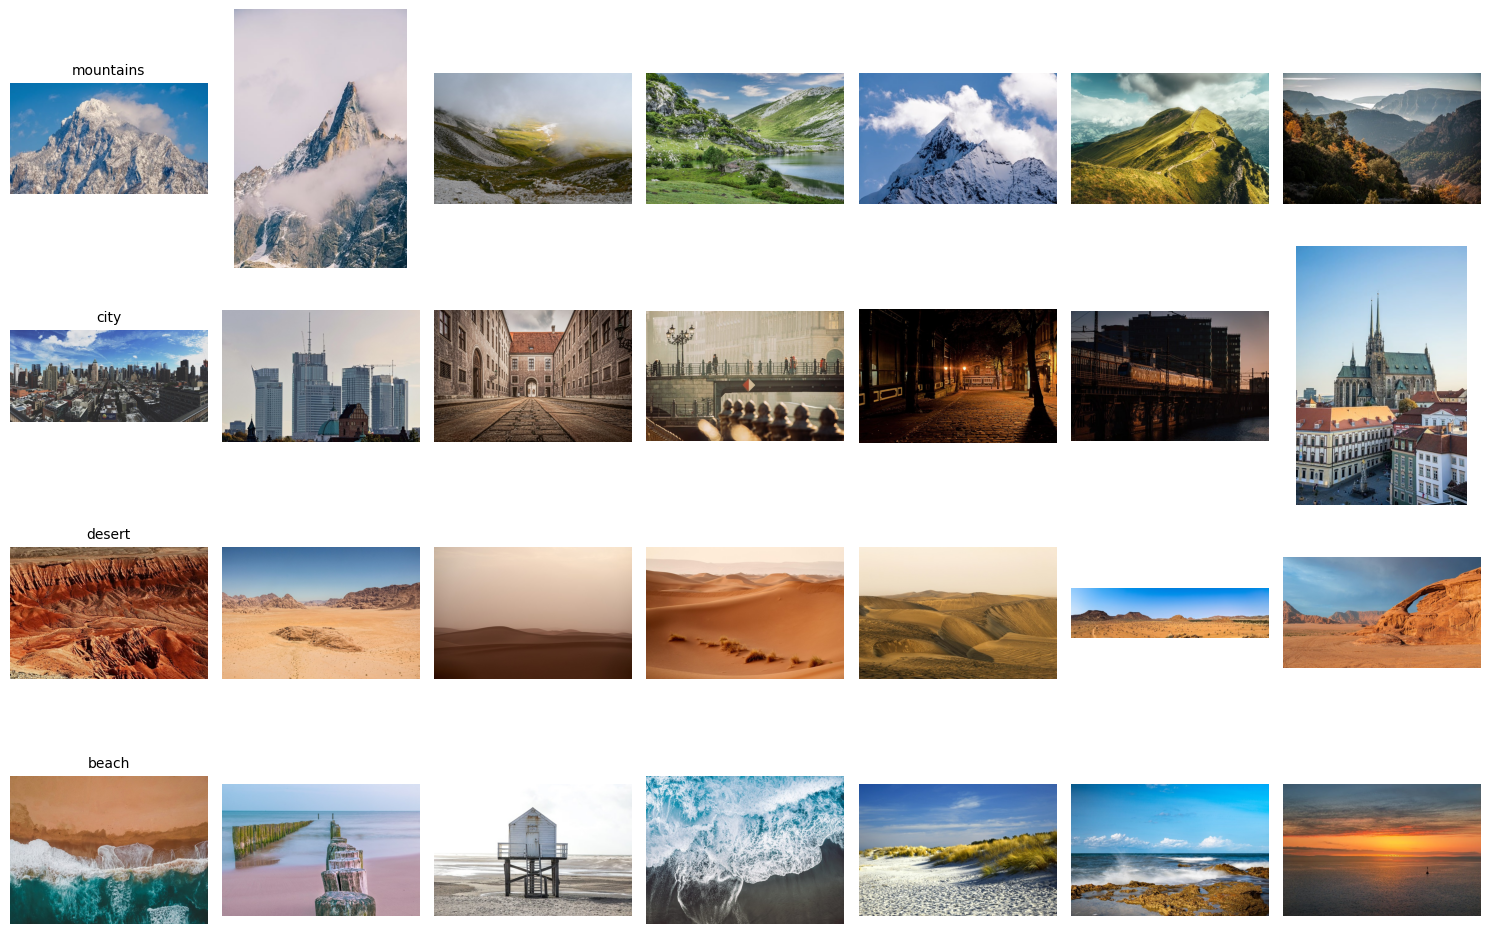

In [ ]:
base_path = 'Dataset'
fig, axs = plt.subplots(len(kategori), 7, figsize=(15, 10))
for row, category in enumerate(kategori):
    folder_path = os.path.join(base_path, category)
    images = os.listdir(folder_path)[3:10]
    for col, image_name in enumerate(images):
        img_path = os.path.join(folder_path, image_name)
        img = Image.open(img_path)
        axs[row, col].imshow(img)
        axs[row, col].axis('off')
        if col == 0:
          axs[row, col].set_title(category, fontsize=10)
plt.tight_layout()
plt.show()


### Data Preprocessing

Karena dataset terdiri dari gambar dengan ukuran piksel yang berbeda-beda, maka dilakukan proses resize agar seluruh gambar memiliki ukuran yang sama. Pada proyek ini, semua gambar akan diubah ukurannya menjadi 224 x 244 piksel.

In [ ]:
def resize(directory, target_dir, size=(224,224)):
  os.makedirs(target_dir, exist_ok=True)
  for filename in os.listdir(directory):
        src_path = os.path.join(directory, filename)
        if os.path.isfile(src_path):
          img = cv2.imread(src_path)
          resized_img = cv2.resize(img, size)
          save_path = os.path.join(target_dir, filename)
          cv2.imwrite(save_path, resized_img)

In [ ]:
resize('Dataset/mountains', 'Dataset_resized/mountain', size=(224, 224))

In [ ]:
resize('Dataset/beach', 'Dataset_resized/beach', size=(224, 224))

In [ ]:
resize('Dataset/desert', 'Dataset_resized/desert', size=(224, 224))


In [ ]:
resize('Dataset/city', 'Dataset_resized/city', size=(224, 224))

In [ ]:
path = './Dataset_resized/'
file_name = []
labels = []
full_path = []

for path, subdirs, files, in os.walk(path):
  for name in files:
    full_path.append(os.path.join(path, name))
    labels.append(path.split('/')[-1])
    file_name.append(name)
df = pd.DataFrame({"path":full_path,'file_name':file_name,"labels":labels})
df.groupby(['labels']).size()

,0
labels,
beach,2728
city,2547
desert,2491
mountain,2710


In [ ]:
X= df['path']
y= df['labels']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
df_tr = pd.DataFrame({'path':X_train,'labels':y_train,'set':'train'})
df_te = pd.DataFrame({'path':X_test,'labels':y_test,'set':'test'})

In [ ]:
df_all = pd.concat([df_tr, df_te], ignore_index=True)

In [ ]:
df_all.to_csv('dataset_info.csv', index=False)

In [ ]:
df_all=pd.read_csv('./dataset_info.csv')

In [ ]:
directory ='./Dataset/'
dataset_final = "Dataset_final/"
for index, row in tqdm(df_all.iterrows()):
    file_path = row['path']
    if os.path.exists(file_path) == False:
            file_path = os.path.join(directory,row['labels'],row['image'].split('.')[0])
    if os.path.exists(os.path.join(dataset_final,row['set'],row['labels'])) == False:
        os.makedirs(os.path.join(dataset_final,row['set'],row['labels']))
    destination_file_name = file_path.split('/')[-1]
    file_dest = os.path.join(dataset_final,row['set'],row['labels'],destination_file_name)
    if os.path.exists(file_dest) == False:
        shutil.copy2(file_path,file_dest)

0it [00:00, ?it/s]

In [ ]:
# Define training and test directories
TRAIN_DIR = "Dataset_final/train/"
TEST_DIR = "Dataset_final/test/"

train_mountain = os.path.join(TRAIN_DIR + '/mountain')
train_beach = os.path.join(TRAIN_DIR + '/beach')
train_desert = os.path.join(TRAIN_DIR + '/desert')
train_city = os.path.join(TRAIN_DIR + '/city')


test_mountain = os.path.join(TEST_DIR + '/mountain')
test_beach = os.path.join(TEST_DIR + '/beach')
test_desert = os.path.join(TEST_DIR + '/desert')
test_city = os.path.join(TEST_DIR + '/city')

print("Total number of mountain images in training set: ",len(os.listdir(train_mountain)))
print("Total number of beach images in training set: ",len(os.listdir(train_beach)))
print("Total number of desert images in training set: ",len(os.listdir(train_desert)))
print("Total number of city images in training set: ",len(os.listdir(train_city)))
print("\n")

print("Total number of mountain images in test set: ",len(os.listdir(test_mountain)))
print("Total number of beach images in test set: ",len(os.listdir(test_beach)))
print("Total number of desert images in test set: ",len(os.listdir(test_desert)))
print("Total number of city images in test set: ",len(os.listdir(test_city)))

Total number of mountain images in training set:  2166
Total number of beach images in training set:  2164
Total number of desert images in training set:  2023
Total number of city images in training set:  2027


Total number of mountain images in test set:  544
Total number of beach images in test set:  564
Total number of desert images in test set:  468
Total number of city images in test set:  520


#### Split Dataset Train, Validation, Test

In [ ]:
datagen = ImageDataGenerator(rescale=1/255.,
                             validation_split = 0.2)
test_datagen = ImageDataGenerator(rescale=1. / 255)

train_generator = datagen.flow_from_directory(TRAIN_DIR,
                                              batch_size=32,
                                              target_size=(150,150),
                                              color_mode="rgb",
                                              class_mode='categorical',
                                              subset='training',
                                              shuffle=True)

validation_generator = datagen.flow_from_directory(TRAIN_DIR,
                                                   batch_size=32,
                                                   target_size=(150,150),
                                                   color_mode="rgb",
                                                   class_mode='categorical',
                                                   subset='validation',
                                                   shuffle=False)

test_generator = test_datagen.flow_from_directory(TEST_DIR,
                                                  batch_size=1,
                                                  target_size=(150,150),
                                                  color_mode="rgb",
                                                  class_mode='categorical',
                                                  shuffle=False)

Found 6706 images belonging to 4 classes.
Found 1674 images belonging to 4 classes.
Found 2096 images belonging to 4 classes.


In [ ]:
model_9 = Sequential([
    Conv2D(32,(3,3), padding='same', activation='relu', input_shape=(150,150,3)),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2,2)),

    Conv2D(32,(4,4), padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2,2)),

    Conv2D(32,(5,5), padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2,2)),

    Conv2D(32,(7,7), padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2,2)),

    Flatten(),

    Dense(256, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),
    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),
    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),

    Dense(4, activation='softmax')

])
model_9.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
%time
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    verbose=1
)

checkpoint = ModelCheckpoint(
    'best_model_v9.h5',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

history = model_9.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=30,
    callbacks=[early_stop, reduce_lr, checkpoint]
)


CPU times: user 4 µs, sys: 0 ns, total: 4 µs
Wall time: 8.34 µs
Epoch 1/30
210/210 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.3264 - loss: 2.0524
Epoch 1: val_accuracy improved from -inf to 0.54540, saving model to best_model_v9.h5


210/210 ━━━━━━━━━━━━━━━━━━━━ 402s 2s/step - accuracy: 0.3267 - loss: 2.0511 - val_accuracy: 0.5454 - val_loss: 1.0901 - learning_rate: 1.0000e-04
Epoch 2/30
210/210 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5827 - loss: 1.1450
Epoch 2: val_accuracy improved from 0.54540 to 0.71565, saving model to best_model_v9.h5


210/210 ━━━━━━━━━━━━━━━━━━━━ 365s 2s/step - accuracy: 0.5828 - loss: 1.1446 - val_accuracy: 0.7157 - val_loss: 0.7536 - learning_rate: 1.0000e-04
Epoch 3/30
210/210 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7065 - loss: 0.8143
Epoch 3: val_accuracy improved from 0.71565 to 0.73835, saving model to best_model_v9.h5


210/210 ━━━━━━━━━━━━━━━━━━━━ 369s 2s/step - accuracy: 0.7066 - loss: 0.8141 - val_accuracy: 0.7384 - val_loss: 0.8142 - learning_rate: 1.0000e-04
Epoch 4/30
210/210 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7630 - loss: 0.6709
Epoch 4: val_accuracy improved from 0.73835 to 0.80346, saving model to best_model_v9.h5


210/210 ━━━━━━━━━━━━━━━━━━━━ 379s 2s/step - accuracy: 0.7630 - loss: 0.6707 - val_accuracy: 0.8035 - val_loss: 0.6221 - learning_rate: 1.0000e-04
Epoch 5/30
210/210 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8166 - loss: 0.5490
Epoch 5: val_accuracy improved from 0.80346 to 0.82915, saving model to best_model_v9.h5


...

210/210 ━━━━━━━━━━━━━━━━━━━━ 381s 2s/step - accuracy: 0.9120 - loss: 0.2692 - val_accuracy: 0.9558 - val_loss: 0.1378 - learning_rate: 1.0000e-04
Epoch 15/30
210/210 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9151 - loss: 0.2686
Epoch 15: val_accuracy did not improve from 0.95579
210/210 ━━━━━━━━━━━━━━━━━━━━ 384s 2s/step - accuracy: 0.9151 - loss: 0.2686 - val_accuracy: 0.9444 - val_loss: 0.1580 - learning_rate: 1.0000e-04
Epoch 16/30
210/210 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9203 - loss: 0.2483
Epoch 16: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.

Epoch 16: val_accuracy did not improve from 0.95579
210/210 ━━━━━━━━━━━━━━━━━━━━ 364s 2s/step - accuracy: 0.9202 - loss: 0.2483 - val_accuracy: 0.9379 - val_loss: 0.1747 - learning_rate: 1.0000e-04
Epoch 17/30
210/210 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9216 - loss: 0.2323
Epoch 17: val_accuracy improved from 0.95579 to 0.95759, saving model to best_model_v9.h5


210/210 ━━━━━━━━━━━━━━━━━━━━ 384s 2s/step - accuracy: 0.9216 - loss: 0.2323 - val_accuracy: 0.9576 - val_loss: 0.1254 - learning_rate: 5.0000e-05
Epoch 18/30
210/210 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9291 - loss: 0.2240
Epoch 18: val_accuracy did not improve from 0.95759
210/210 ━━━━━━━━━━━━━━━━━━━━ 368s 2s/step - accuracy: 0.9291 - loss: 0.2240 - val_accuracy: 0.9492 - val_loss: 0.1508 - learning_rate: 5.0000e-05
Epoch 19/30
210/210 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9302 - loss: 0.2345
Epoch 19: val_accuracy improved from 0.95759 to 0.95938, saving model to best_model_v9.h5


210/210 ━━━━━━━━━━━━━━━━━━━━ 367s 2s/step - accuracy: 0.9302 - loss: 0.2345 - val_accuracy: 0.9594 - val_loss: 0.1217 - learning_rate: 5.0000e-05
Epoch 20/30
210/210 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9390 - loss: 0.2080
Epoch 20: val_accuracy improved from 0.95938 to 0.96356, saving model to best_model_v9.h5


210/210 ━━━━━━━━━━━━━━━━━━━━ 380s 2s/step - accuracy: 0.9390 - loss: 0.2080 - val_accuracy: 0.9636 - val_loss: 0.1092 - learning_rate: 5.0000e-05
Epoch 21/30
210/210 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9430 - loss: 0.1871
Epoch 21: val_accuracy did not improve from 0.96356
210/210 ━━━━━━━━━━━━━━━━━━━━ 367s 2s/step - accuracy: 0.9430 - loss: 0.1871 - val_accuracy: 0.9624 - val_loss: 0.1234 - learning_rate: 5.0000e-05
Epoch 22/30
210/210 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9386 - loss: 0.2109
Epoch 22: val_accuracy did not improve from 0.96356
210/210 ━━━━━━━━━━━━━━━━━━━━ 362s 2s/step - accuracy: 0.9386 - loss: 0.2108 - val_accuracy: 0.9636 - val_loss: 0.1071 - learning_rate: 5.0000e-05
Epoch 23/30
210/210 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9472 - loss: 0.1702
Epoch 23: val_accuracy improved from 0.96356 to 0.97312, saving model to best_model_v9.h5


210/210 ━━━━━━━━━━━━━━━━━━━━ 401s 2s/step - accuracy: 0.9472 - loss: 0.1703 - val_accuracy: 0.9731 - val_loss: 0.0861 - learning_rate: 5.0000e-05
Epoch 24/30
210/210 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9504 - loss: 0.1695
Epoch 24: val_accuracy did not improve from 0.97312
210/210 ━━━━━━━━━━━━━━━━━━━━ 405s 2s/step - accuracy: 0.9503 - loss: 0.1696 - val_accuracy: 0.9588 - val_loss: 0.1177 - learning_rate: 5.0000e-05
Epoch 25/30
210/210 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9404 - loss: 0.1903
Epoch 25: ReduceLROnPlateau reducing learning rate to 2.499999936844688e-05.

Epoch 25: val_accuracy did not improve from 0.97312
210/210 ━━━━━━━━━━━━━━━━━━━━ 363s 2s/step - accuracy: 0.9404 - loss: 0.1903 - val_accuracy: 0.9630 - val_loss: 0.1099 - learning_rate: 5.0000e-05
Epoch 26/30
210/210 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9455 - loss: 0.1741
Epoch 26: val_accuracy did not improve from 0.97312
210/210 ━━━━━━━━━━━━━━━━━━━━ 360s 2s/step - accuracy: 0.9455 - loss: 0

In [ ]:
best_val_acc = max(model_9.history['val_accuracy'])
print(f"Best Validation Accuracy: {best_val_acc:.4f}")

Best Validation Accuracy: 0.9731


Model berhasil mencapai performa validasi yang sangat baik dengan akurasi validasi tertinggi sebesar **97.31%** pada epoch ke-23.

## Evaluasi dan Visualisasi

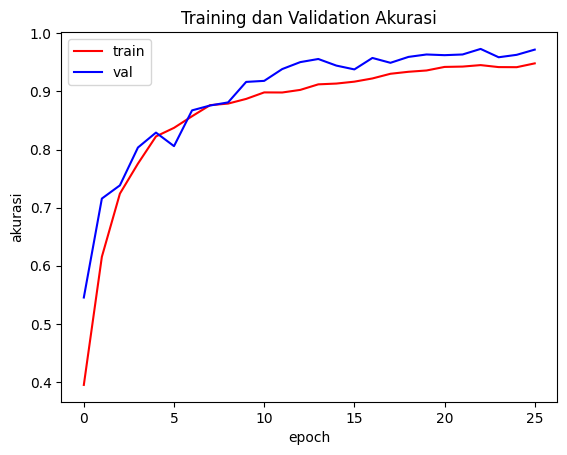

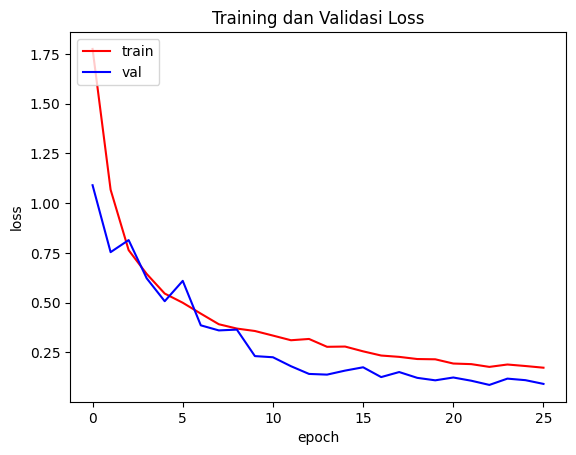

In [ ]:
akurasi = history.history['accuracy']
val_akurasi = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(len(akurasi))
plt.plot(epochs, akurasi, 'r')
plt.plot(epochs, val_akurasi, 'b')
plt.title('Training dan Validation Akurasi')
plt.xlabel('epoch')
plt.ylabel('akurasi')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

plt.plot(epochs, loss, 'r')
plt.plot(epochs, val_loss, 'b')
plt.title('Training dan Validasi Loss')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

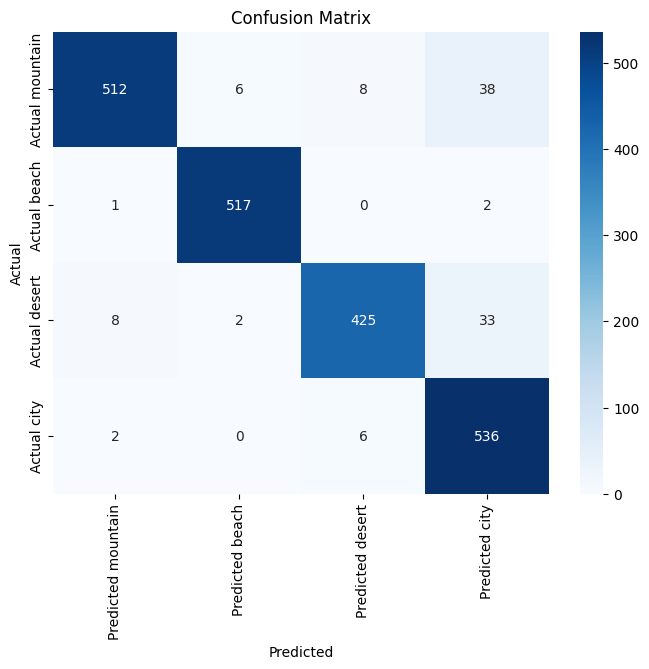


Classification Report:

              precision    recall  f1-score   support

    mountain     0.9790    0.9078    0.9420       564
       beach     0.9848    0.9942    0.9895       520
      desert     0.9681    0.9081    0.9372       468
        city     0.8801    0.9853    0.9297       544

    accuracy                         0.9494      2096
   macro avg     0.9530    0.9489    0.9496      2096
weighted avg     0.9523    0.9494    0.9495      2096



In [ ]:
test_generator.reset()

preds_9 = model_9.predict(test_generator, verbose=0)
pred_labels = np.argmax(preds_9, axis=1)

cm = pd.DataFrame(
    data=confusion_matrix(test_generator.classes, pred_labels, labels=[0, 1, 2, 3]),
    index=["Actual mountain", "Actual beach", "Actual desert", "Actual city"],
    columns=["Predicted mountain", "Predicted beach", "Predicted desert", "Predicted city"]
)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix')
plt.show()

print("\nClassification Report:\n")
print(classification_report(
    y_true=test_generator.classes,
    y_pred=pred_labels,
    target_names=['mountain', 'beach', 'desert', 'city'],
    digits=4
))

Model menunjukkan performa yang sangat baik dengan **akurasi keseluruhan sebesar 95%** pada data uji. Detail per kelas:

1. Beach memiliki performa terbaik dengan precision dan recall hampir sempurna (98.48% dan 99.42%), artinya hampir semua gambar pantai dikenali dengan benar.

2. Desert dan Mountain juga tampil baik, meskipun recall sedikit lebih rendah (90–91%), menunjukkan ada beberapa gambar padang pasir dan gunung yang salah klasifikasi.

3. City memiliki precision paling rendah (88.01%), artinya model masih sering salah mengklasifikasikan gambar kota sebagai kelas lain, meskipun recall-nya sangat tinggi (98.53%)



## Konversi Model

### **1. SavedModel**

In [ ]:
model_9.save('final_model_v9.keras')

In [ ]:
model = load_model('final_model_v9.keras')
model.export('saved_model')


/usr/local/lib/python3.11/dist-packages/keras/src/saving/saving_lib.py:757: UserWarning: Skipping variable loading for optimizer 'rmsprop', because it has 112 variables whereas the saved optimizer has 222 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Saved artifact at 'saved_model'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 150, 150, 3), dtype=tf.float32, name='input_layer_1')
Output Type:
  TensorSpec(shape=(None, 4), dtype=tf.float32, name=None)
Captures:
  138206395089168: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138206395090512: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138206395090896: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138206395090704: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138206395089360: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138206395092048: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138206395092432: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138206395092816: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138206395092624: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138206395089936: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138206395093968: T

### **2. TF-Lite**

In [ ]:
converter = tf.lite.TFLiteConverter.from_saved_model('saved_model')
tflite_model = converter.convert()
with open('model.tflite', 'wb') as f:
    f.write(tflite_model)

### **3. TFJS**

In [ ]:
!pip install tensorflowjs

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.1/89.1 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.0/53.0 kB 4.5 MB/s eta 0:00:00
  Attempting uninstall: packaging
    Found existing installation: packaging 24.2
    Uninstalling packaging-24.2:
      Successfully uninstalled packaging-24.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-cloud-bigquery 3.31.0 requires packaging>=24.2.0, but you have packaging 23.2 which is incompatible.


In [ ]:
!tensorflowjs_converter \
    --input_format=tf_saved_model \
    --output_format=tfjs_graph_model \
    saved_model/ \
    tfjs_model/

2025-05-02 06:25:07.535084: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1746167107.576805   68743 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1746167107.588399   68743 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
🌲 Try https://ydf.readthedocs.io, the successor of TensorFlow Decision Forests with more features and faster training!
2025-05-02 06:25:12.832985: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)
I0000 00:00:1746167114.197950   68743 devices.cc:67] Number of eligible GPUs (core count >= 8, compute capability >= 0.0): 0
I0000 00:00

## Inference

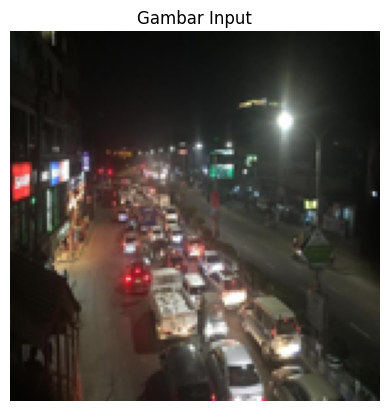

Label Kelas Terprediksi: city


In [ ]:
model_path = './saved_model/'
model = tf.keras.layers.TFSMLayer(model_path, call_endpoint='serving_default')

def inference(image_path):
    img = Image.open(image_path).resize((150, 150))
    img_array = np.array(img).astype('float32') / 255.0

    if img_array.shape[-1] == 4:
        img_array = img_array[..., :3]

    img_array = np.expand_dims(img_array, axis=0)
    plt.imshow(img)
    plt.title("Gambar Input")
    plt.axis('off')
    plt.show()
    predictions = model(img_array)
    pred_array = list(predictions.values())[0].numpy()
    predicted_class = np.argmax(pred_array, axis=-1)
    class_labels = ['mountain', 'beach', 'desert', 'city']
    predicted_label = class_labels[predicted_class[0]]
    print("Label Kelas Terprediksi:", predicted_label)

image_path = './model inference/5.jpg'
inference(image_path)

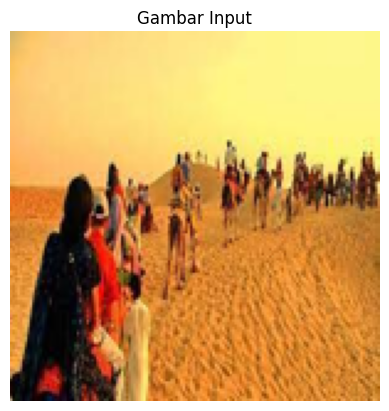

Label Kelas Terprediksi: desert


In [ ]:
image_path = './model inference/3.jpeg'
inference(image_path)

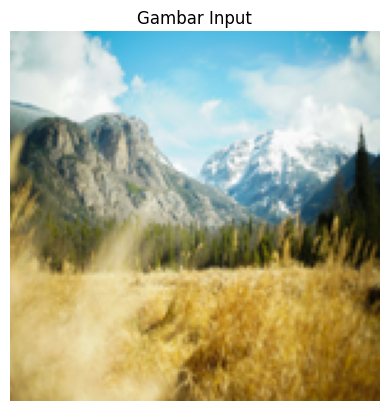

Label Kelas Terprediksi: mountain


In [ ]:
image_path = './model inference/8.jpg'
inference(image_path)

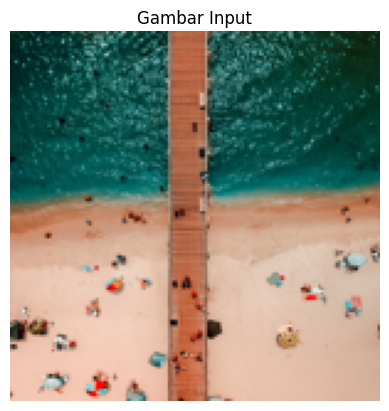

Label Kelas Terprediksi: beach


In [ ]:
image_path = './model inference/9.jpg'
inference(image_path)

## Kesimpulan

Model telah dilatih dengan stabil dan berhasil mencapai performa yang sangat baik dalam klasifikasi gambar empat kelas: mountain, beach, desert, dan city.

* **Akurasi validasi terbaik sebesar 97%** dicapai pada epoch ke-23, dan model terbaik disimpan secara otomatis.

* Evaluasi Model pada Data Uji,
Berdasarkan classification report terhadap 2096 sampel uji:

* **Akurasi keseluruhan: 95%**, menunjukkan model mampu mengklasifikasikan mayoritas gambar dengan benar.

* Beach adalah kelas paling akurat, dengan precision dan recall > 98%, yang berarti gambar pantai sangat mudah dikenali oleh model.

* Desert dan Mountain juga cukup kuat, meskipun terdapat beberapa salah klasifikasi.

* City memiliki precision paling rendah (88.01%), yang mengindikasikan model masih sering keliru saat mengidentifikasi gambar kota sebagai kelas lain kemungkinan karena kemiripan visual dengan kelas lainnya.

* Dan dari hasil model inference telah dilakukan percobaan, dan menghasilkan label gambar yang tepat sesuai dengan gambar input yang diberikan

In [ ]:
import matplotlib
import sklearn
import PIL
import tqdm


In [ ]:
print("TensorFlow:", tf.__version__)
print("Pandas:", pd.__version__)
print("NumPy:", np.__version__)
print("Seaborn:", sns.__version__)
print("Matplotlib:", matplotlib.__version__)
print("Scikit-learn:", sklearn.__version__)
print("OpenCV:", cv2.__version__)
print("Pillow (PIL):", PIL.__version__)
print("tqdm:", tqdm.__version__)

TensorFlow: 2.18.0
Pandas: 2.2.2
NumPy: 2.0.2
Seaborn: 0.13.2
Matplotlib: 3.10.0
Scikit-learn: 1.6.1
OpenCV: 4.11.0
Pillow (PIL): 11.2.1
tqdm: 4.67.1
